# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Deutsch–Jozsa Algorithm

Generalised 3-Qubit Deutsch-Jozsa Analysis

1. Circuit Visualisation

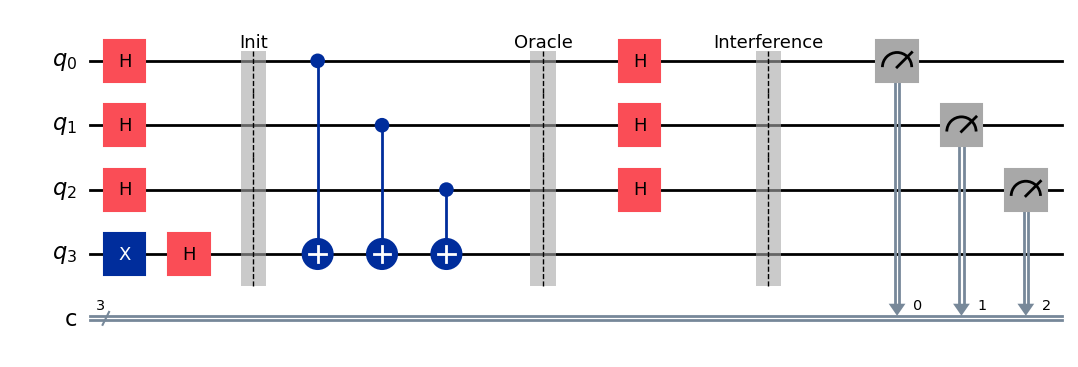

2. Unitary Evolution

The 16x16 unitary matrix describing the full circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>


Final DensityMatrix prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


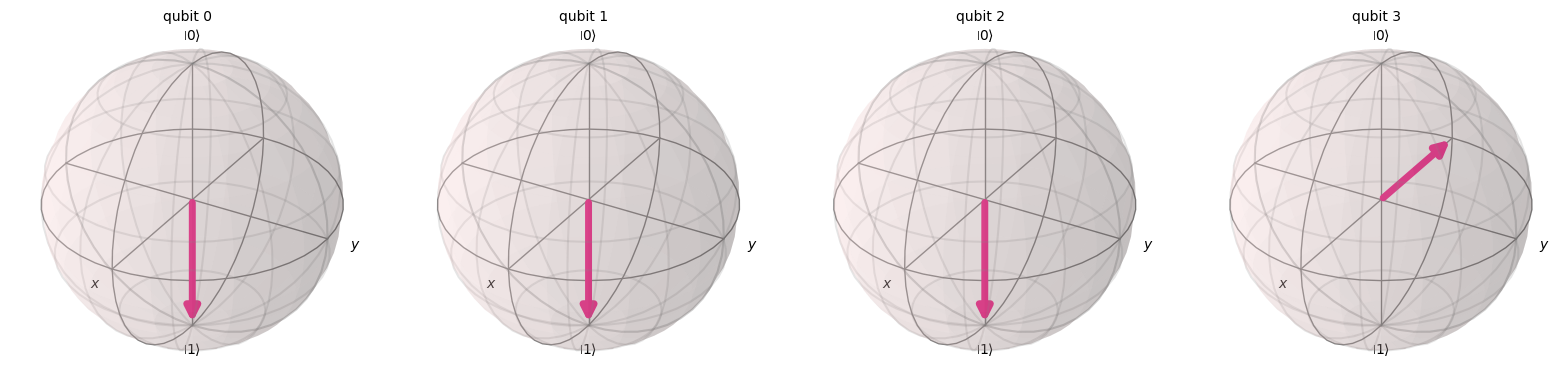


State prior to measurement (Q-Sphere):


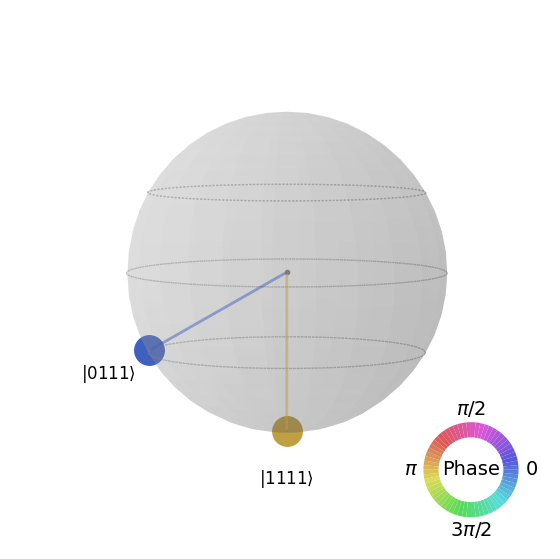

5. Measurement Analysis

Raw measurement counts: {'111': 1024}


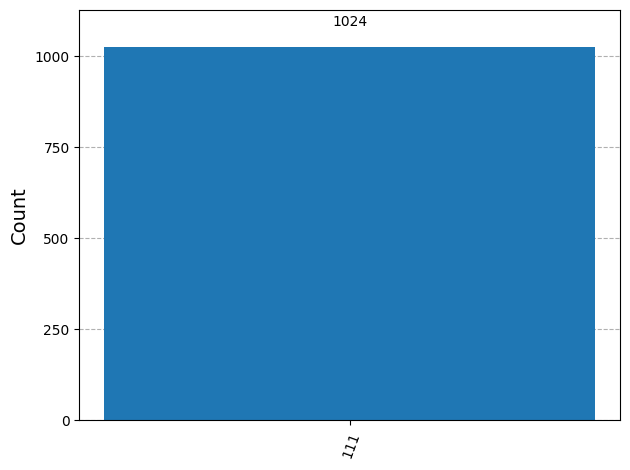

6. Verification

Conclusion: 100% of measurements returned '111'. The function is BALANCED.


In [54]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
n = 3                     # Number of input qubits
oracle_type = "balanced"  # Choose: 'constant' or 'balanced'
# If balanced, choose which qubits are involved in the XOR (e.g., [0, 1, 2] for all)
# Using [1, 2] is equivalent to your 'x2_xor_x3' case (using 0-based indexing)
balanced_qubits = [0, 1, 2] 

# 1. Set up Registers & Circuit
qr = QuantumRegister(n + 1, name="q")
cr = ClassicalRegister(n, name="c")
qc = QuantumCircuit(qr, cr)

# 2. Initialisation
qc.x(n) # Prepare target qubit in |1>
for i in range(n + 1):
    qc.h(i) # Apply Hadamard to all qubits (inputs enter |+>, target enters |->)
qc.barrier(label="Init")

# 3. Oracle Construction
if oracle_type == "constant":
    # Randomly assign f(x) = 0 (do nothing) or f(x) = 1 (apply X to target)
    if np.random.randint(2) == 1:
        qc.x(n)
elif oracle_type == "balanced":
    # Apply CNOTs from specified input qubits to the target qubit
    for q in balanced_qubits:
        qc.cx(q, n)
qc.barrier(label="Oracle")

# 4. Final Interference
for i in range(n):
    qc.h(i)
qc.barrier(label="Interference")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
# Extract mathematical representations before measurement collapses the state
unitary = Operator(qc)
final_state = Statevector(qc)
final_density = DensityMatrix(qc)

# 5. Measurement (measure only the input register)
for i in range(n):
    qc.measure(i, i)

# 6. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"Generalised {n}-Qubit Deutsch-Jozsa Analysis"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
# Note: For large n, the unitary matrix (size 2^(n+1) x 2^(n+1)) becomes unwieldy to display.
if n <= 3:
    print(f"The {2**(n+1)}x{2**(n+1)} unitary matrix describing the full circuit:")
    display(array_to_latex(unitary.data, prefix="U_{circuit} = ", max_size=16))
else:
    print(f"Unitary matrix omitted: {n} input qubits results in a matrix too large for clean display.")

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

print("\nFinal DensityMatrix prior to measurement:")
display(final_density.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 6. Final Verification Logic
display(Markdown("6. Verification"))
measured_bitstring = list(counts.keys())[0]
zero_string = '0' * n

if measured_bitstring == zero_string:
    print(f"Conclusion: 100% of measurements returned '{zero_string}'. The function is CONSTANT.")
else:
    print(f"Conclusion: 100% of measurements returned '{measured_bitstring}'. The function is BALANCED.")